# Week 10 - Bank Churn

---



Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [ ]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Work/PORTFOLIO/DATA ANALYTICS/Machine Learning Endeavor (Customer Churn)/data/bank_churn_data.csv')

In [ ]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
#### Shape
pdf.shape

(10127, 23)

In [ ]:
#### Null
pdf.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [ ]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [ ]:
#### First 5 rows
pdf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## A. Univariate analysis including histogram and box plot with written description of the following variables:

### i. Customer_Age

In [ ]:
#### i. Customer_Age summary statistics
pdf['Customer_Age'].describe()

,Customer_Age
count,10127.000000
mean,46.325960
std,8.016814
min,26.000000
25%,41.000000
50%,46.000000
75%,52.000000
max,73.000000


<Axes: ylabel='Frequency'>

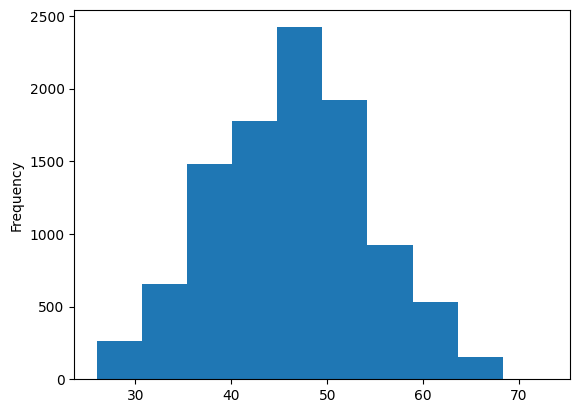

In [ ]:
#### i. Customer_Age histogram
pdf['Customer_Age'].plot(kind='hist')

Based on the graph, the primary customer base is concentrated between 40 and 50 years old, with a peak at age 46. While this middle-aged segment is our strongest driver of revenue, the data reveals significant growth potential in younger and older demographics, especially in the younger segment. I recommend implementing age-based segmentation to refine our marketing. This strategy will allow us to maintain the loyalty of our core customers while developing targeted outreach to capture the underserved segments of the market.

<Axes: >

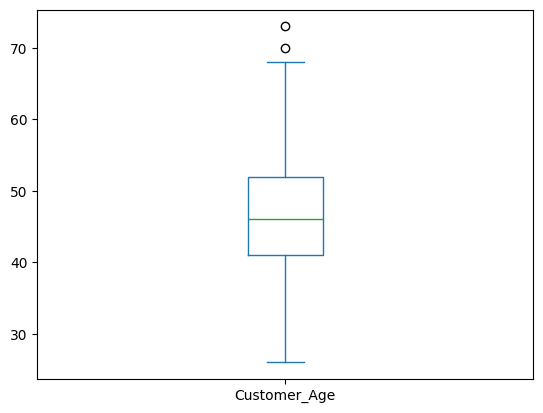

In [ ]:
#### i. Customer_Age boxplot
pdf['Customer_Age'].plot(kind='box')

Similar to the previous graph, the box indicates that the majority of the customers are concentrated inside 40 to 50 year old range, however there's still a dispersion of a significant amount of customer presence below and above that boundary. As recommended before it will be beneficial to increase efforts in targeting other customer age segments especially below the 40 year old range. It is also important to note the outliers present in the graph.

### ii. Dependent_count

In [ ]:
#### ii. Dependent_count summary statistics
pdf['Dependent_count'].describe()

,Dependent_count
count,8101.000000
mean,2.334773
std,1.289564
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


<Axes: ylabel='Frequency'>

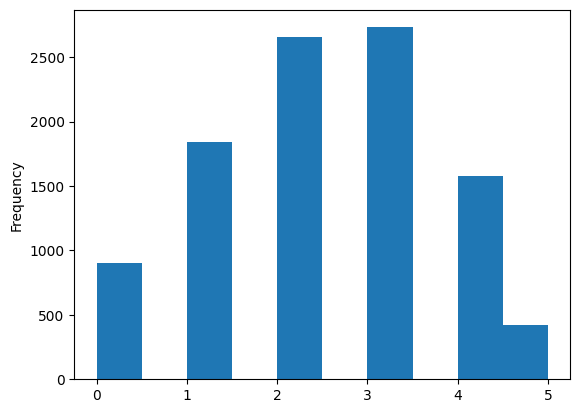

In [ ]:
#### ii. Dependent_count histogram
pdf['Dependent_count'].plot(kind='hist')

Based on the histogram, having 2 to 3 dependent cards is the most common, with customer counts gradually declining as the number of dependents increases. Far fewer customers have 0 or 5 dependents compared to those with 1 to 4. Customers with more dependents may represent families with greater financial needs and potentially higher spending, making them strong targets for loyalty programs and rewards to encourage engagement and spending.

<Axes: >

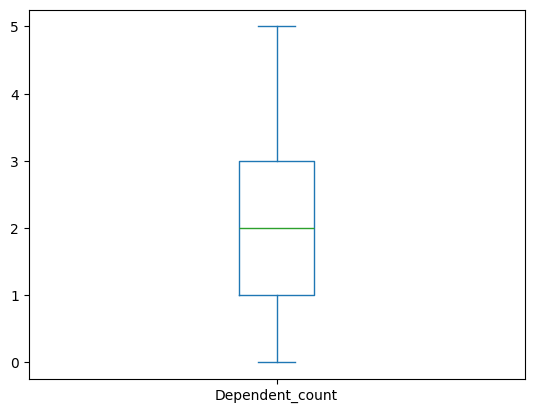

In [ ]:
#### ii. Dependent_count boxplot
pdf['Dependent_count'].plot(kind='box')

Using a box plot we can still see the same conclusion that most customers have between 1 and 3 dependent cards, indicating that the significant portion of the customer base likely consists of families or individuals with dependents. There are no outliers in the data.

### iii. Months_Inactive_12_mon

In [ ]:
#### iii. Months_Inactive_12_mon summary statistics
pdf['Months_Inactive_12_mon'].describe()

,Months_Inactive_12_mon
count,10127.000000
mean,2.341167
std,1.010622
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,6.000000


<Axes: ylabel='Frequency'>

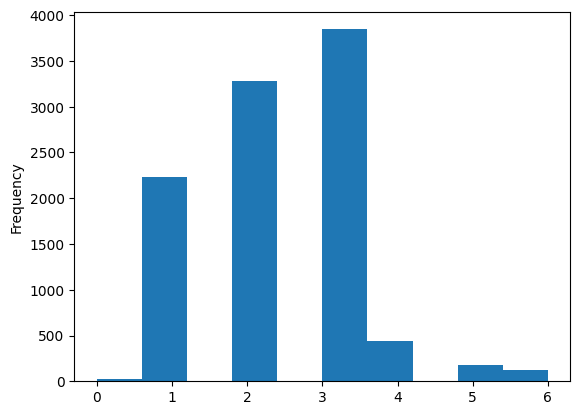

In [ ]:
#### iii. Months_Inactive_12_mon histogram
pdf['Months_Inactive_12_mon'].plot(kind='hist')

The histogram shows that the highest frequency (3) in months 1 to 3, indicating most customers become inactive very early after acquisition. Frequencies drop sharply afterward, with months 0, 4, 5, and 6 showing near-zero activity. The 1-3 month inactivity stat is crucial for customer retention, in order to make the customers engage within this inactivity period different marketing strategies, or promo campaigns should be held to increase customer engagement, as well as gathering feedback to understand the pain points of their 1-3 months of inactivity.

<Axes: >

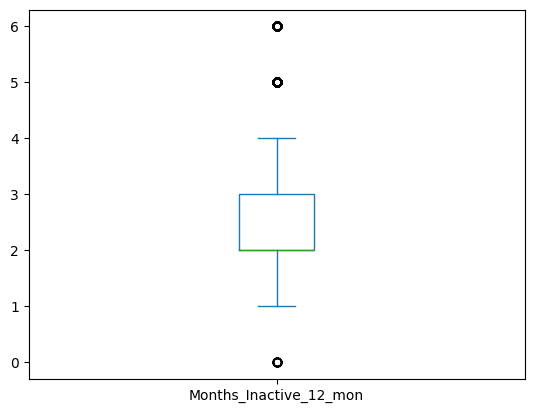

In [ ]:
#### iii. Months_Inactive_12_mon boxplot
pdf['Months_Inactive_12_mon'].plot(kind='box')

Analyzing the data using box plot, we still see that 2 to 3 months of inactivity is the norm, which often extends to 4 or even 6 months based on the outliers, but only to a handful of people. Having 0 months as an outlier can mean that almost every customer is inactive for 2-3 months upon the last bank transaction. Therefore, why this happens should be discovered one way or another in order to foster a more interactive ecosystem between the bank and the customers

### iv. Credit_Limit

In [ ]:
#### iv. Credit_Limit summary statistics
pdf['Credit_Limit'].describe()

,Credit_Limit
count,10127.000000
mean,8631.953698
std,9088.776650
min,1438.300000
25%,2555.000000
50%,4549.000000
75%,11067.500000
max,34516.000000


<Axes: ylabel='Frequency'>

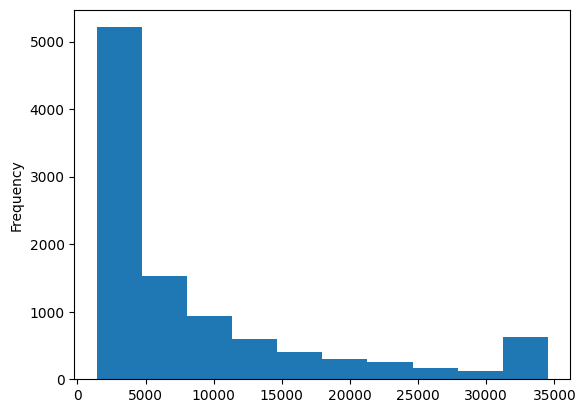

In [ ]:
#### iv. Credit_Limit histogram
pdf['Credit_Limit'].plot(kind='hist')

The histogram indicates a right-skewed distribution of credit limits, where most customers fall within the lower credit limit ranges (roughly 1,000–5,000). As the credit limit increases, the number of customers steadily declines, with only a small portion holding very high limits up to around 35,000. This suggests the majority of customers maintain modest credit limits, while a limited group represents high-credit customers. The company could consider strategic credit limit increases for customers with strong repayment behavior to encourage higher spending while maintaining responsible risk management.

<Axes: >

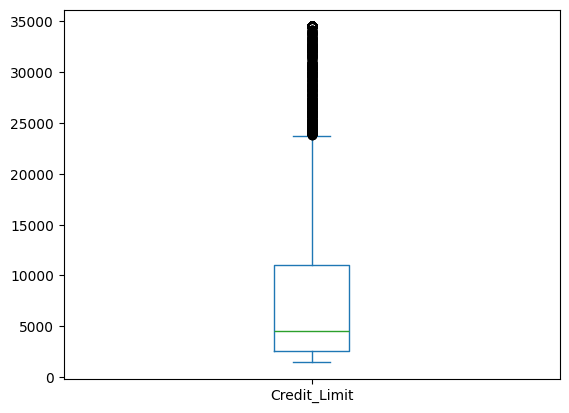

In [ ]:
#### iv. Credit_Limit boxplot
pdf['Credit_Limit'].plot(kind='box')

The box plot shows that the middle 50% of customers have credit limits between approximately 2500 and 11000, with a median around the lower end of this range. Numerous outliers above 22,000 indicate a smaller group of customers with significantly higher credit limits compared to the majority. This suggests that while most customers maintain moderate limits, a select segment holds premium credit lines.

### v. Total_Trans_Amt

In [ ]:
#### v. Total_Trans_Amt summary statistics
pdf['Total_Trans_Amt'].describe()

,Total_Trans_Amt
count,10127.000000
mean,4404.086304
std,3397.129254
min,510.000000
25%,2155.500000
50%,3899.000000
75%,4741.000000
max,18484.000000


<Axes: ylabel='Frequency'>

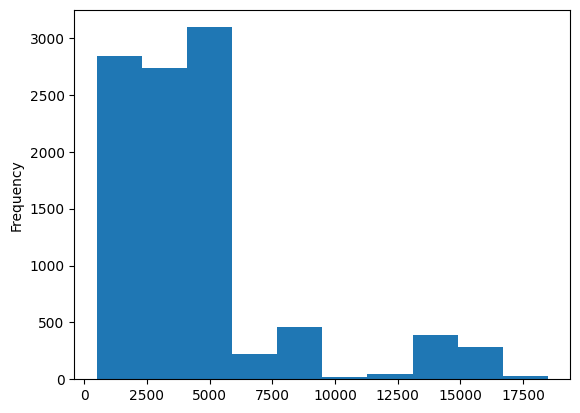

In [ ]:
#### v. Total_Trans_Amt histogram
pdf['Total_Trans_Amt'].plot(kind='hist')

The histogram shows a right-skewed distribution of total transaction amounts, where most customers fall within the 0–5000 range, indicating moderate spending levels for the majority. As transaction amounts increase, the number of customers declines, with only a small segment showing significantly higher spending. This pattern suggests an opportunity to use transaction data for customer segmentation and targeted marketing, while continuously monitoring spending behavior to adapt strategies and identify high-value customers.

<Axes: >

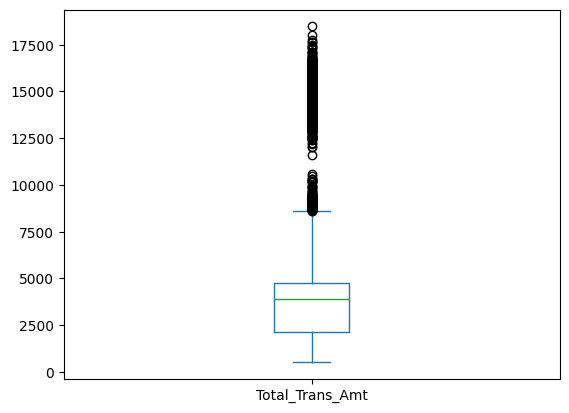

In [ ]:
#### v. Total_Trans_Amt box plot
pdf['Total_Trans_Amt'].plot(kind='box')

Using box plot, similar to the previous analysis most transaction amounts fall between 2000 to 4700 (clearer range based on the box), indicating a concentration of customers within this spending range. There are outliers exceeding 7500, suggesting a small number of customers with significantly higher transaction amounts. Also, the presence of outliers highlights the need to consider them separately (high spenders vs moderate spenders) when analyzing spending patterns.

## B. Univariate analysis including bar plot with written description for:

### i. Attrion_Flag

In [ ]:
#### i. Count Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
0,8500
1,1627


<Axes: xlabel='Attrition_Flag'>

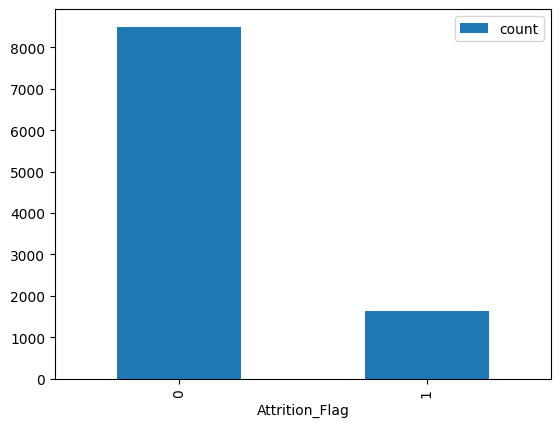

In [ ]:
#### i. Plot Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts().plot(kind='bar', legend=True)

Analyzing the customer attrition flag, there's till a lot of customer who remained loyal with the company. The bank is doing an excellent job in retaining customers however it's still important to discover the pain points of the customers who left regardless of how large of small their number is.

## C. Bivariate analysis including descriptive statistics and bar plot with written description for the following pair of variables:

### Descriptive Statistics

In [ ]:
#### Descriptive statistics
pdf[['Customer_Age', 'Dependent_count', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt']].describe()

,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,2.341167,8631.953698,4404.086304
std,8.016814,1.298908,1.010622,9088.776650,3397.129254
min,26.000000,0.000000,0.000000,1438.300000,510.000000
25%,41.000000,1.000000,2.000000,2555.000000,2155.500000
50%,46.000000,2.000000,2.000000,4549.000000,3899.000000
75%,52.000000,3.000000,3.000000,11067.500000,4741.000000
max,73.000000,5.000000,6.000000,34516.000000,18484.000000


### i. Customer_Age vs Attrition_Flag

In [ ]:
#### i. mean of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Customer_Age']

,Customer_Age
Attrition_Flag,
0,46.262118
1,46.659496


<Axes: xlabel='Attrition_Flag'>

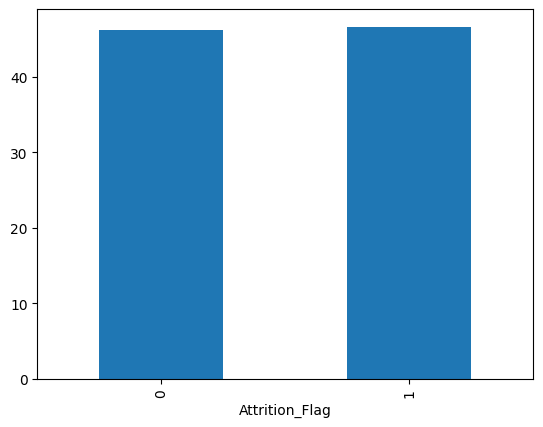

In [ ]:
#### i. Bar Plot Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Customer_Age'].plot(kind='bar')

Analyzing the attrition flag based on customer age, we can deduce that that customers who left and stayed belong to the same average age bracket. Therefore, we can say age as a variable is not a great factor in accounting customer retention or their churn in itself, if combined with other factors it might make more sense.

### ii. Dependent_count vs Attrition_Flag

In [ ]:
#### ii. mean Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Dependent_count']

,Dependent_count
Attrition_Flag,
0,2.335412
1,2.402581


<Axes: xlabel='Attrition_Flag'>

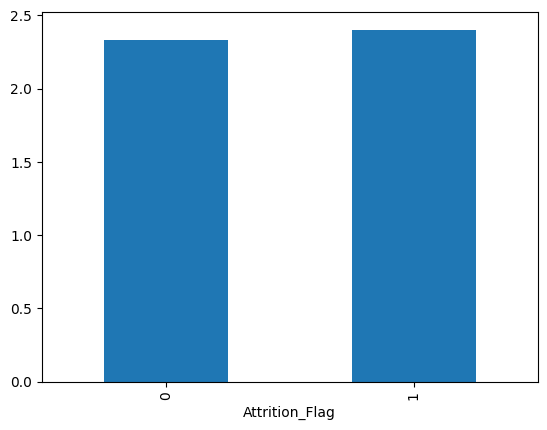

In [ ]:
#### ii. Bar Plot Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Dependent_count'].plot(kind='bar')

Similarly, flagging attrition together with dependent count, we can see a very likened result just like the previous analysis. We really can't derive an impactful conclusion using a customer's dependent count and their attrition rate, for, both flags are similar through the mean of the dependent count.

### iii. Months_Inactive_12_mon vs Attrition_Flag

In [ ]:
#### iii. mean Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Months_Inactive_12_mon']

,Months_Inactive_12_mon
Attrition_Flag,
0,2.273765
1,2.693301


<Axes: xlabel='Attrition_Flag'>

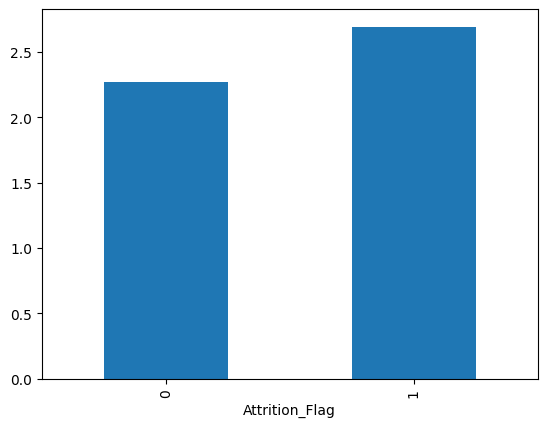

In [ ]:
#### iii. Bar Plot Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Months_Inactive_12_mon'].plot(kind='bar')

However, using months of inactivity flag we can derive a more plausible take that attrited customers was seen to be more on the inactive side of things compared to customers who were retained which was found to be more engaged and transacted frequently with the bank.

### iv. Credit_Limit vs Attrition_Flag

In [ ]:
#### iv. mean Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Credit_Limit']

,Credit_Limit
Attrition_Flag,
0,8726.877518
1,8136.039459


<Axes: xlabel='Attrition_Flag'>

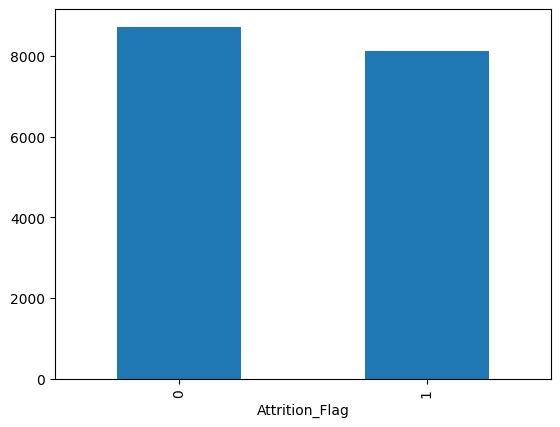

In [ ]:
#### iv. Bar Plot Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Credit_Limit'].plot(kind='bar')

On the other hand, using credit limit as the comparison we can see a slight difference. Customers who stayed have a slightly higher average credit limit compared to those who left. There is a small margin of possibility that credit limit is a strong indicator of customer retention or their churn, which is why it is impotant to know more about customers sentiments based on their credit limit, spending habits, capacity to pay, and other factors related to it.

### v. Total_Trans_Amt vs Attrition_Flag

In [ ]:
#### v. mean Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Total_Trans_Amt']

,Total_Trans_Amt
Attrition_Flag,
0,4654.655882
1,3095.025814


<Axes: xlabel='Attrition_Flag'>

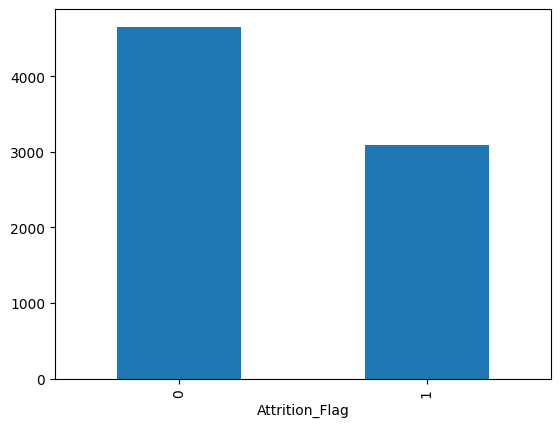

In [ ]:
#### v. Bar Plot Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean(numeric_only=True)['Total_Trans_Amt'].plot(kind='bar')

Lastly, using ustomers total transaction amount we can deduce that those who have churned was found to have a lower average total transaction amount compared to the customers who were retained. This indicates that customers who spent/transacted less money with the bank are more likely to churn.


This is a valuable indicator for predicting customer churn, together with credit limit and inactivity factors, we can formulate a cohesive conclusion that those who have a larger transaction flexibility (higher credit limit) tend to be more active in transacting using the banks services therefore prolonging customer retention, while those on the opposite end, having lower credit limit, therefore having less spending power, was seen to churn